In [2]:
import gzip
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Carrega o dataset MNIST do arquivo .pkl.gz
with gzip.open('datasets/mnist.pkl.gz', 'rb') as f:
    train_set, valid_set, test_set = pickle.load(f, encoding='latin1')

In [4]:
# Dados de treino, validação e teste
X_train, y_train = train_set
X_valid, y_valid = valid_set
X_test, y_test = test_set

In [5]:
# Junta treino e validação para uma base de 60.000 amostras
X = np.concatenate([X_train, X_valid])
y = np.concatenate([y_train, y_valid])

print("Shape dos dados (X):", X.shape)
print("Shape dos rótulos (y):", y.shape)

Shape dos dados (X): (60000, 784)
Shape dos rótulos (y): (60000,)


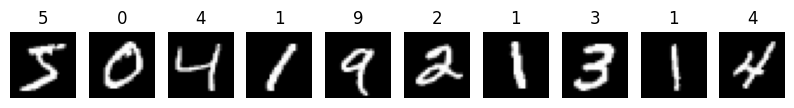

In [6]:
# Função para plotar dígitos
def plot_digits(images, labels, n=10):
    plt.figure(figsize=(n, 1.5))
    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        ax.imshow(images[i].reshape(28, 28), cmap='gray')
        ax.set_title(int(labels[i]))
        ax.axis('off')
    plt.show()

# Exibe os primeiros 10 dígitos
plot_digits(X, y)

C:\Users\celso\AppData\Local\Temp\ipykernel_34472\665545117.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='tab10')


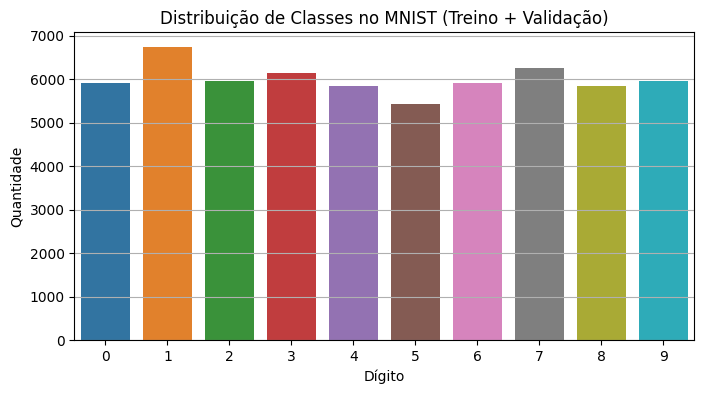

In [7]:
import pandas as pd
import seaborn as sns

# Cria um DataFrame para facilitar a contagem e visualização
df = pd.DataFrame({'label': y})

# Plot da distribuição de classes
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='label', palette='tab10')
plt.title('Distribuição de Classes no MNIST (Treino + Validação)')
plt.xlabel('Dígito')
plt.ylabel('Quantidade')
plt.grid(axis='y')
plt.show()


In [8]:
# Calcula a média e o desvio padrão de todos os pixels (784 dimensões)
pixel_means = X.mean(axis=0)
pixel_stds = X.std(axis=0)

print("Média geral dos pixels:", X.mean())
print("Desvio padrão geral dos pixels:", X.std())

Média geral dos pixels: 0.13015018
Desvio padrão geral dos pixels: 0.30690408


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import time

# Inicia o temporizador
start = time.time()

# Aplica K-means com 10 clusters pois já sabemos as classes
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

# Calcula o ARI
ari_kmeans = adjusted_rand_score(y, kmeans_labels)

print("Adjusted Rand Index (K-means - dados originais):", round(ari_kmeans, 4))
print("Tempo de execução:", round(time.time() - start, 2), "s")

Adjusted Rand Index (K-means - dados originais): 0.3609
Tempo de execução: 83.43 s


In [10]:
from sklearn.cluster import AgglomerativeClustering

# Aplica o agrupamento hierárquico
agg = AgglomerativeClustering(n_clusters=10, linkage='ward')
agg_labels = agg.fit_predict(X)

# ARI
ari_agg = adjusted_rand_score(y, agg_labels)
print("Adjusted Rand Index (Hierárquico - Ward - dados originais):", round(ari_agg, 4))

Adjusted Rand Index (Hierárquico - Ward - dados originais): 0.5966


In [9]:
from sklearn.cluster import DBSCAN
from sklearn.utils import resample

# Amostra 10 mil exemplos aleatórios
X_sample, y_sample = resample(X, y, n_samples=10000, random_state=42)

# Aplica DBSCAN com parâmetros ajustados
dbscan = DBSCAN(eps=1000, min_samples=5, n_jobs=-1)
db_labels = dbscan.fit_predict(X_sample)

# Verifica número de clusters e outliers
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f"Número de clusters encontrados (sem contar ruído): {n_clusters}")
print(f"Número de amostras consideradas ruído (-1): {n_noise}")

# ARI
if n_clusters > 1:
    ari_dbscan = adjusted_rand_score(y_sample, db_labels)
    print("Adjusted Rand Index (DBSCAN - dados originais, amostra):", round(ari_dbscan, 4))
else:
    print("DBSCAN não encontrou clusters suficientes para calcular ARI.")


Número de clusters encontrados (sem contar ruído): 1
Número de amostras consideradas ruído (-1): 0
DBSCAN não encontrou clusters suficientes para calcular ARI.


In [10]:
from sklearn.decomposition import PCA

# Aplica PCA para reduzir os dados a 2 dimensões
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

# Mostra a variância explicada por cada componente
print("Variância explicada por componente:", pca_2d.explained_variance_ratio_)
print("Variância total explicada (2D):", sum(pca_2d.explained_variance_ratio_))


Variância explicada por componente: [0.09704664 0.07095924]
Variância total explicada (2D): 0.16800587624311447


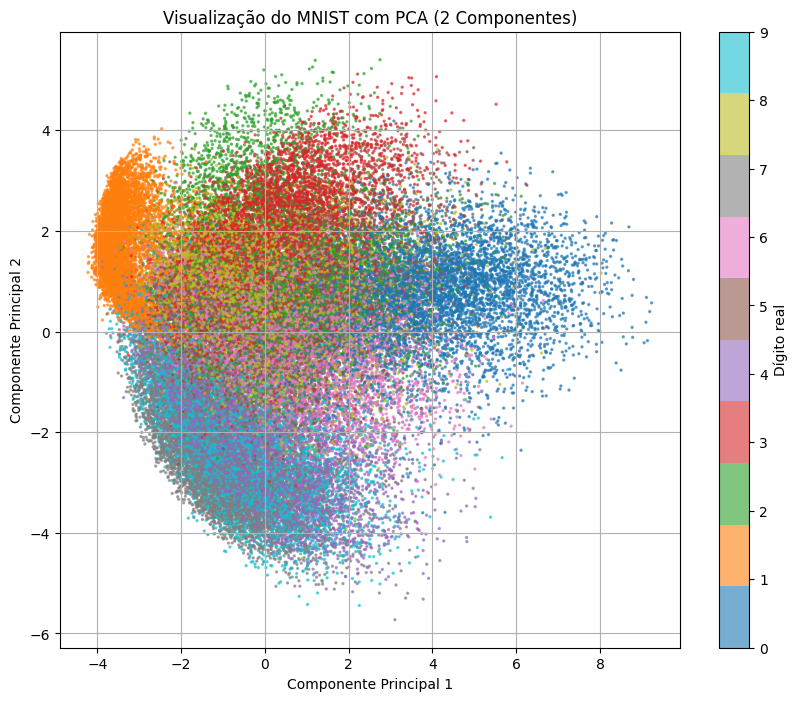

In [11]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='tab10', s=2, alpha=0.6)
plt.colorbar(scatter, ticks=range(10), label='Dígito real')
plt.title('Visualização do MNIST com PCA (2 Componentes)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()


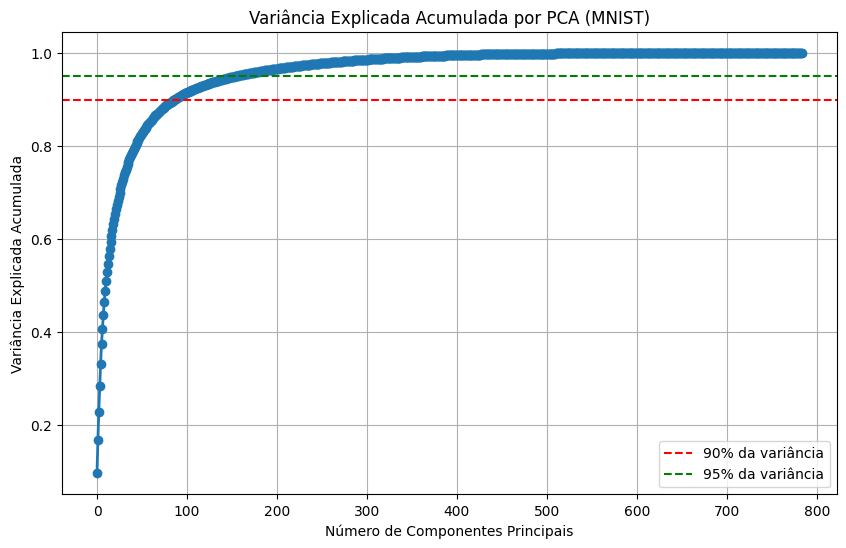

In [12]:
# PCA com todos os componentes possíveis (até 784)
pca_full = PCA(n_components=784)
pca_full.fit(X)

# Variância explicada acumulada
varac = np.cumsum(pca_full.explained_variance_ratio_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(varac, marker='o', linewidth=2)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% da variância')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% da variância')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Variância Explicada Acumulada por PCA (MNIST)')
plt.grid(True)
plt.legend()
plt.show()


In [13]:
# PCA com 180 componentes principais
pca_180 = PCA(n_components=180)
X_pca_180 = pca_180.fit_transform(X)

# Verifica quanta variância foi explicada
print("Variância total explicada com 180 componentes:", round(sum(pca_180.explained_variance_ratio_), 4))

Variância total explicada com 180 componentes: 0.9603


In [16]:
# K-means nos dados com PCA (180 componentes)
kmeans_pca = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans_labels_pca = kmeans_pca.fit_predict(X_pca_180)

# Avalia o ARI
ari_kmeans_pca = adjusted_rand_score(y, kmeans_labels_pca)
print("ARI (K-means com PCA 180):", round(ari_kmeans_pca, 4))


ARI (K-means com PCA 180): 0.3608


In [17]:
# Hierárquico com linkage 'ward'
agg_pca = AgglomerativeClustering(n_clusters=10, linkage='ward')
agg_labels_pca = agg_pca.fit_predict(X_pca_180)

# ARI
ari_agg_pca = adjusted_rand_score(y, agg_labels_pca)
print("ARI (Hierárquico com PCA 180):", round(ari_agg_pca, 4))

ARI (Hierárquico com PCA 180): 0.5413


In [24]:
from sklearn.utils import resample

# Amostragem de 10.000 pontos
X_sample_pca, y_sample_pca = resample(X_pca_180, y, n_samples=10000, random_state=42)

# DBSCAN com PCA nos dados amostrados
dbscan_pca_sample = DBSCAN(eps=5, min_samples=5, n_jobs=-1)
db_labels_pca_sample = dbscan_pca_sample.fit_predict(X_sample_pca)

# Verificação
n_clusters_sample = len(set(db_labels_pca_sample)) - (1 if -1 in db_labels_pca_sample else 0)
n_noise_sample = list(db_labels_pca_sample).count(-1)

print(f"Número de clusters (sem ruído): {n_clusters_sample}")
print(f"Número de amostras como ruído: {n_noise_sample}")

# ARI
if n_clusters_sample > 1:
    ari_dbscan_sample = adjusted_rand_score(y_sample_pca, db_labels_pca_sample)
    print("ARI (DBSCAN com PCA 180 - amostra):", round(ari_dbscan_sample, 4))
else:
    print("DBSCAN não encontrou clusters suficientes.")


Número de clusters (sem ruído): 20
Número de amostras como ruído: 4134
ARI (DBSCAN com PCA 180 - amostra): 0.0771
